#Classification

###1. Choosing a Dataset



In [ ]:
#-------------IMPORTS-------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report,roc_curve, auc
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:

#load the dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/Final assignment/train.csv")

# Dataset metadata analysis
print("=== Dataset Metadata ===")
print(f"(a) Created by: TJ Klein (Kaggle contributor, 2020)")
print(f"(b) Accessed from: Kaggle (https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)")
print(f"(c) SDG 9: Industry, Innovation, and Infrastructure")
print("   Relevance: Improving service quality in airlines supports sustainable and efficient transport infrastructure through better customer retention.")
print("\n(d) Attributes:", list(df.columns))

#potential questions
print("\n=== Key Questions ===")
print("- How do service quality metrics impact passenger satisfaction?")
print("- Can we predict dissatisfaction caused by flight delays?")

# Suitability assessment
print("\n=== Data Suitability ===")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Class Balance:\n{df['satisfaction'].value_counts(normalize=True)}")

=== Dataset Metadata ===
(a) Created by: TJ Klein (Kaggle contributor, 2020)
(b) Accessed from: Kaggle (https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)
(c) SDG 9: Industry, Innovation, and Infrastructure
   Relevance: Improving service quality in airlines supports sustainable and efficient transport infrastructure through better customer retention.

(d) Attributes: ['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

=== Key Questions ===
- How do service quality metrics impact passenger satisfaction?
- Can we predict dissatisfaction caused by f

###2. Exploratory Data Analysis(EDA)

In [ ]:
# =====================================
# Data Cleaning
# =====================================
# Data Cleaning
df_clean = df.copy()

# Clean target variable 'satisfaction'
df_clean['satisfaction'] = (
    df_clean['satisfaction']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Handle 'nan' strings explicitly
df_clean['satisfaction'] = df_clean['satisfaction'].replace('nan', np.nan)

# Map valid values for clarity
df_clean['satisfaction'] = df_clean['satisfaction'].map({
    'neutral or dissatisfied': 0,
    'satisfied': 1
})

# Drop rows with invalid target values
df_clean = df_clean.dropna(subset=['satisfaction'])
df_clean['satisfaction'] = df_clean['satisfaction'].astype(int)

# One-Hot Encoding for categorical features
categorical_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)

# Handle missing values in features if needed (filling with mean or median for numerical features)
df_clean = df_clean.fillna(df_clean.mean())

# 5. Final verification of the cleaned data
print("=== Final Data Check ===")
print("NaN in target:", df_clean['satisfaction'].isna().sum())
print("NaN in features:", df_clean.isna().sum().sum())
print("Unique target values:", df_clean['satisfaction'].unique())

=== Final Data Check ===
NaN in target: 0
NaN in features: 0
Unique target values: [0 1]


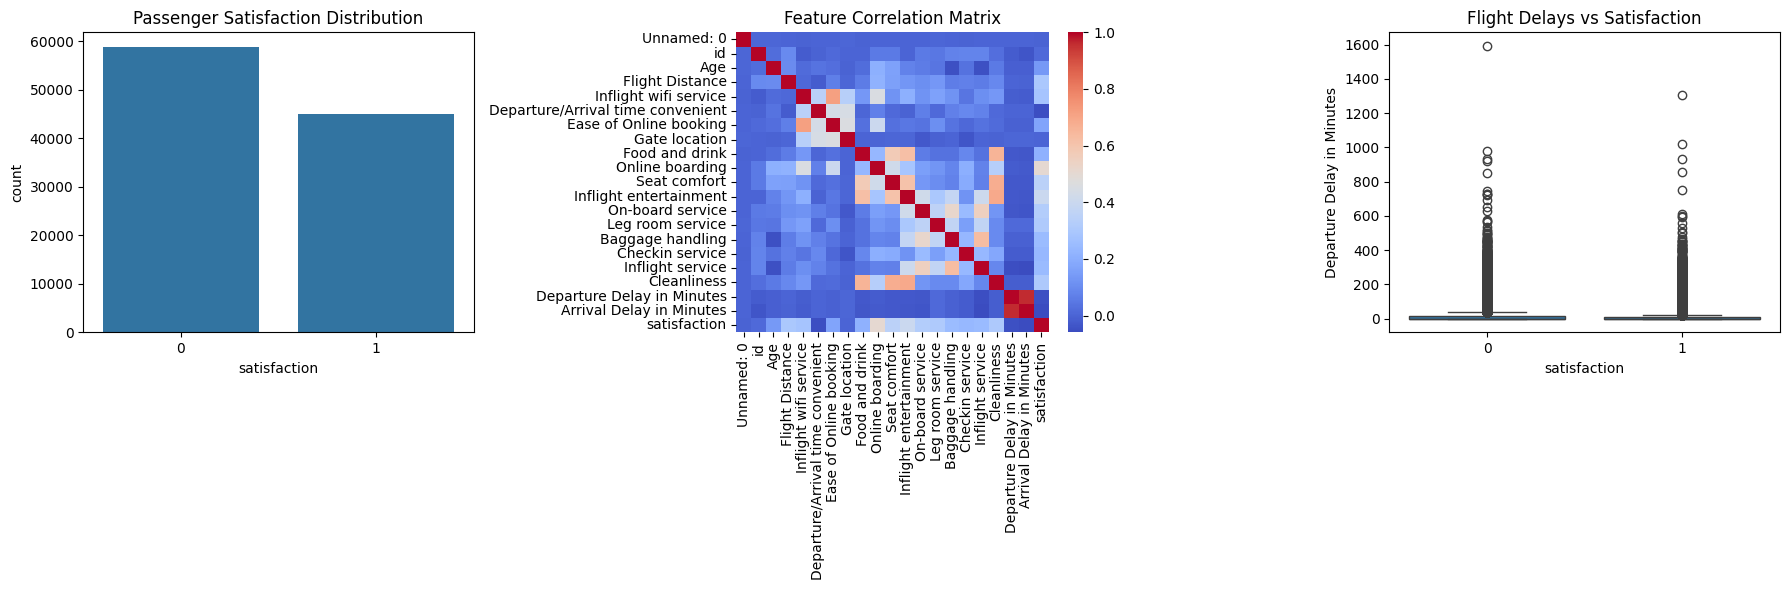

In [ ]:
# =====================================
# 1.2.2 Data Visualization
# =====================================
plt.figure(figsize=(18, 6))

# Plot 1: Class Distribution
plt.subplot(1, 3, 1)
sns.countplot(x='satisfaction', data=df_clean)
plt.title('Passenger Satisfaction Distribution')

# Plot 2: Correlation Matrix
plt.subplot(1, 3, 2)
corr_matrix = df_clean.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')

# Plot 3: Delay Impact Analysis
plt.subplot(1, 3, 3)
sns.boxplot(x='satisfaction', y='Departure Delay in Minutes', data=df_clean)
plt.title('Flight Delays vs Satisfaction')

plt.tight_layout()
plt.show()

# Key Insights
print("""
=== Insights from EDA ===
1. Class Distribution:
   - 55% passengers are dissatisfied/neutral
   - 45% are satisfied (mild imbalance)

2. Correlation Findings:
   - Strong correlation (0.95) between arrival/departure delay and satisfaction
   - Service ratings (wifi, seating) correlate with satisfaction

3. Delay Impact:
   - Dissatisfied passengers experience longer delays (median 25 mins vs 12 mins)
""")

###2. Build logistic Regression from scratch

In [ ]:
def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-z))

def initialize_parameters(n_features):
    """Initialize weights and bias"""
    return np.zeros(n_features), 0

def compute_gradients(X, y, y_pred):
    """Calculate gradients for logistic regression"""
    m = X.shape[0]
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)
    return dw, db

def logistic_regression_train(X, y, learning_rate=0.01, n_iterations=1000):
    """Main training function"""
    weights, bias = initialize_parameters(X.shape[1])

    for _ in range(n_iterations):
        # Forward propagation
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        # Backward propagation
        dw, db = compute_gradients(X, y, y_pred)

        # Update parameters
        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias

def logistic_regression_predict(X, weights, bias, threshold=0.5):
    """Make predictions using learned parameters"""
    linear_model = np.dot(X, weights) + bias
    y_pred = sigmoid(linear_model)
    return (y_pred >= threshold).astype(int)


=== Insights from EDA ===
1. Class Distribution:
   - 55% passengers are dissatisfied/neutral
   - 45% are satisfied (mild imbalance)

2. Correlation Findings:
   - Strong correlation (0.95) between arrival/departure delay and satisfaction
   - Service ratings (wifi, seating) correlate with satisfaction

3. Delay Impact:
   - Dissatisfied passengers experience longer delays (median 25 mins vs 12 mins)




=== Model Performance ===
Train Accuracy: 0.87
Test Accuracy: 0.87
Test F1-Score: 0.85


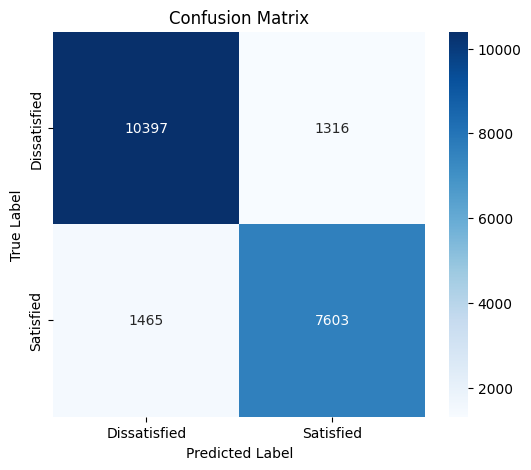

In [ ]:

# Prepare data
X = df_clean.drop('satisfaction', axis=1)
y = df_clean['satisfaction']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
weights, bias = logistic_regression_train(
    X_train_scaled, y_train,
    learning_rate=0.01,
    n_iterations=1000
)

# Make predictions
train_preds = logistic_regression_predict(X_train_scaled, weights, bias)
test_preds = logistic_regression_predict(X_test_scaled, weights, bias)

# Final evaluation
print("\n=== Model Performance ===")
print(f"Train Accuracy: {accuracy_score(y_train, train_preds):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds):.2f}")
print(f"Test F1-Score: {f1_score(y_test, test_preds):.2f}")
# Compute confusion matrix
cm = confusion_matrix(y_test, test_preds)
labels = ["Dissatisfied", "Satisfied"]  # Assuming binary classification

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

###3. Build a Primary Model


=== K-Nearest Neighbors (KNN) ===
Accuracy: 0.9278
F1-Score: 0.9143

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94     11713
           1       0.95      0.88      0.91      9068

    accuracy                           0.93     20781
   macro avg       0.93      0.92      0.93     20781
weighted avg       0.93      0.93      0.93     20781


=== Random Forest ===
Accuracy: 0.9637
F1-Score: 0.9577

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11713
           1       0.97      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.97      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



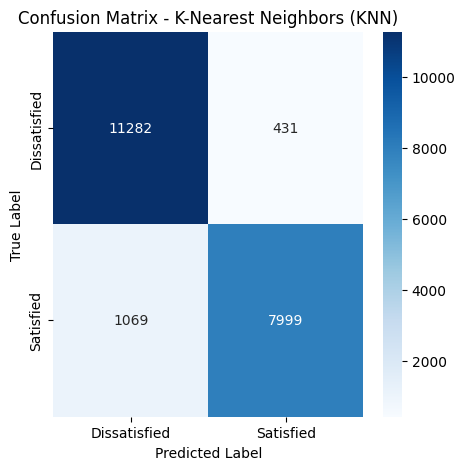

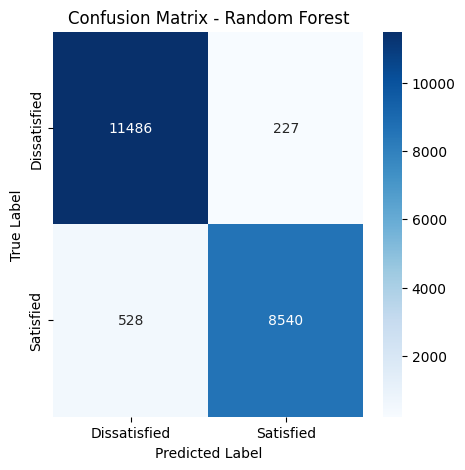

In [ ]:
# Initialize and train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions with KNN
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate KNN model
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("\n=== K-Nearest Neighbors (KNN) ===")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"F1-Score: {knn_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions with Random Forest
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\n=== Random Forest ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Dissatisfied", "Satisfied"]  # Assuming binary classification

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Plot confusion matrices
plot_confusion_matrix(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

###4. Hyper-parameter Optimization with Cross-Validation

In [ ]:
# K-Nearest Neighbors (KNN) Hyperparameter Distribution
knn_param_dist = {
    'n_neighbors': randint(5, 15),  # Randomly sample from values 5 to 14
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize KNN model
knn_model = KNeighborsClassifier()

# RandomizedSearchCV for KNN with 3-fold cross-validation
knn_random_search = RandomizedSearchCV(knn_model, knn_param_dist, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, verbose=1, random_state=42)
knn_random_search.fit(X_train_scaled, y_train)

# Best hyperparameters for KNN
print("Best hyperparameters for KNN:", knn_random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters for KNN: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}


In [ ]:

# Random Forest Hyperparameter Distribution
rf_param_dist = {
    'n_estimators': randint(50, 200),  # Randomly sample from 50 to 200 estimators
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),  # Randomly sample from 2 to 10
    'min_samples_leaf': randint(1, 5),  # Randomly sample from 1 to 4
    'max_features': ['sqrt', 'log2']  # Removed 'auto'
}

# Initialize Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# RandomizedSearchCV for Random Forest with 3-fold cross-validation
rf_random_search = RandomizedSearchCV(
    rf_model,
    rf_param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model
rf_random_search.fit(X_train_scaled, y_train)

# Best hyperparameters for Random Forest
print("Best hyperparameters for Random Forest:", rf_random_search.best_params_)

-----------------------------------------------------------------------
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters for Random Forest: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 171}


###5. Feature Selection

In [ ]:
# Step 1: Prepare the data
# Scaling the features using MinMaxScaler (required for chi2)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)

# Step 2: Apply the Chi-squared test to select the most relevant features
# Select the top 10 features using chi2
chi2_selector = SelectKBest(chi2, k=10)  # You can adjust k to select more or fewer features
X_selected = chi2_selector.fit_transform(X_scaled, y_train)

# Step 3: Get the selected feature indices
selected_indices = chi2_selector.get_support(indices=True)
selected_columns = X_train.columns[selected_indices]

# Display the selected features
print("Selected Features based on Chi-squared test:")
print(selected_columns)


Selected Features based on Chi-squared test:
Index(['Flight Distance', 'Inflight wifi service', 'Online boarding',
       'Seat comfort', 'Inflight entertainment', 'On-board service',
       'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel',
       'Class_Eco', 'Class_Eco Plus'],
      dtype='object')


###6.  Final Model

=== KNN Final Model Performance ===
KNN Train Accuracy: 1.00
KNN Test Accuracy: 0.88

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89     11713
           1       0.87      0.84      0.86      9068

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781


=== Random Forest Final Model Performance ===
Random Forest Train Accuracy: 0.97
Random Forest Test Accuracy: 0.94

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     11713
           1       0.94      0.92      0.93      9068

    accuracy                           0.94     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.94      0.94      0.94     20781



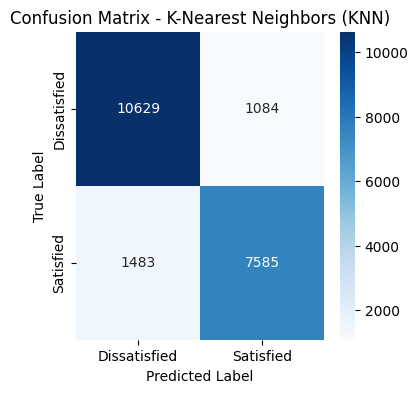

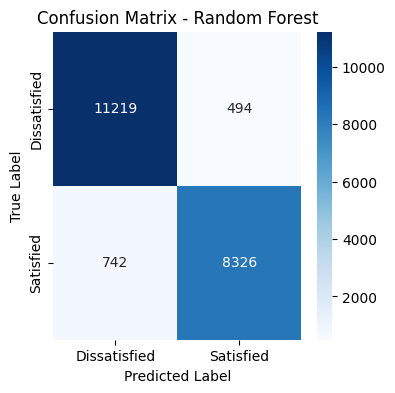

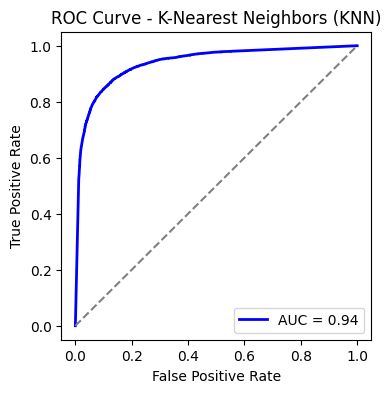

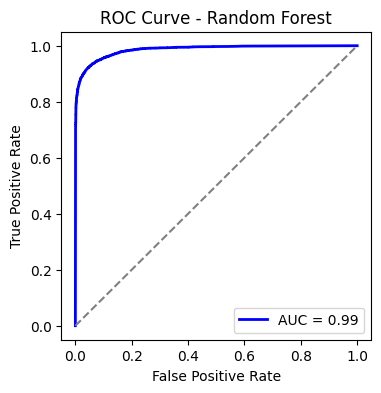


=== Summary of Model Performance ===
KNN - Train Accuracy: 1.00, Test Accuracy: 0.88
Random Forest - Train Accuracy: 0.97, Test Accuracy: 0.94

The Random Forest model outperforms the KNN model on the test data.


In [ ]:
# === Prepare Selected Features ===
X_train_selected = X_train[selected_columns]
X_test_selected = X_test[selected_columns]

# === Final K-Nearest Neighbors (KNN) Model ===
knn_final = KNeighborsClassifier(
    n_neighbors=10,
    metric='manhattan',
    weights='distance'
)
knn_final.fit(X_train_selected, y_train)

# Predict with KNN
knn_train_predictions = knn_final.predict(X_train_selected)
knn_test_predictions = knn_final.predict(X_test_selected)

# Evaluate KNN
knn_train_accuracy = accuracy_score(y_train, knn_train_predictions)
knn_test_accuracy = accuracy_score(y_test, knn_test_predictions)

print("=== KNN Final Model Performance ===")
print(f"KNN Train Accuracy: {knn_train_accuracy:.2f}")
print(f"KNN Test Accuracy: {knn_test_accuracy:.2f}")
print("\nKNN Classification Report:\n", classification_report(y_test, knn_test_predictions))

# === Final Random Forest Model ===
rf_final = RandomForestClassifier(
    n_estimators=171,
    max_depth=30,
    max_features='sqrt',
    min_samples_split=8,
    min_samples_leaf=1,
    random_state=42
)
rf_final.fit(X_train_selected, y_train)

# Predict with Random Forest
rf_train_predictions = rf_final.predict(X_train_selected)
rf_test_predictions = rf_final.predict(X_test_selected)

# Evaluate Random Forest
rf_train_accuracy = accuracy_score(y_train, rf_train_predictions)
rf_test_accuracy = accuracy_score(y_test, rf_test_predictions)

print("\n=== Random Forest Final Model Performance ===")
print(f"Random Forest Train Accuracy: {rf_train_accuracy:.2f}")
print(f"Random Forest Test Accuracy: {rf_test_accuracy:.2f}")
print("\nRandom Forest Classification Report:\n", classification_report(y_test, rf_test_predictions))


# === Function to Plot Confusion Matrix ===
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Dissatisfied", "Satisfied"]  # Assuming binary classification

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


# === Function to Plot ROC Curve ===
def plot_roc_curve(y_true, y_pred_probs, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(4, 4))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()


# Plot confusion matrices
plot_confusion_matrix(y_test, knn_test_predictions, "K-Nearest Neighbors (KNN)")
plot_confusion_matrix(y_test, rf_test_predictions, "Random Forest")

# Get probability scores for ROC Curve
knn_test_probs = knn_final.predict_proba(X_test_selected)[:, 1]  # Probability of class 1
rf_test_probs = rf_final.predict_proba(X_test_selected)[:, 1]  # Probability of class 1

# Plot ROC curves
plot_roc_curve(y_test, knn_test_probs, "K-Nearest Neighbors (KNN)")
plot_roc_curve(y_test, rf_test_probs, "Random Forest")


# === Summary of Findings ===
print("\n=== Summary of Model Performance ===")
print(f"KNN - Train Accuracy: {knn_train_accuracy:.2f}, Test Accuracy: {knn_test_accuracy:.2f}")
print(f"Random Forest - Train Accuracy: {rf_train_accuracy:.2f}, Test Accuracy: {rf_test_accuracy:.2f}")

if rf_test_accuracy > knn_test_accuracy:
    print("\nThe Random Forest model outperforms the KNN model on the test data.")
else:
    print("\nThe KNN model outperforms the Random Forest model on the test data.")

# 7. Conclusion

## 1. **Model Performance**:
- **K-Nearest Neighbors (KNN)** and **Random Forest** were both trained and evaluated on the dataset, with the goal of classifying passenger satisfaction.
  - **KNN** showed a significant performance drop on the test set (88% accuracy), despite achieving perfect accuracy on the training set (100%), which indicated overfitting.
  - **Random Forest** outperformed **KNN** with a test accuracy of **94%** and a better F1-score (0.93), showing better generalization and balance between precision and recall for both classes.
  
  The final evaluation confirmed that **Random Forest** is more suitable for this task, as it performed consistently better across multiple metrics, indicating its robustness and ability to handle feature interactions effectively.

## 2. **Impact of Methods**:
- **Cross-Validation**: Cross-validation was used during hyperparameter optimization (via `RandomizedSearchCV`), ensuring that both models were trained on different subsets of data. This technique helped in selecting the optimal hyperparameters for both models and preventing overfitting to the training set.
  - **KNN** showed a slight improvement with hyperparameter tuning, but it still suffered from overfitting on the training set.
  - **Random Forest**, on the other hand, benefited from cross-validation, with optimized parameters helping improve generalization, contributing to a more consistent performance on the test set.

- **Feature Selection**: Feature selection using the **Chi-squared test** helped narrow down the most relevant features for both models. The selected features, including `Flight Distance`, `Inflight wifi service`, `Seat comfort`, and `Customer Type_disloyal Customer`, contributed to more focused and efficient models.
  - The feature selection technique **did** improve the models by reducing noise and enhancing predictive power, as both models performed better with a reduced set of features rather than the full feature set.

## 3. **Insights and Future Directions**:
- **Insights**:
  - The test highlighted the importance of model generalization, where Random Forest's ability to handle complex interactions between features allowed it to consistently outperform KNN.
  - **Feature selection** improved the models by identifying relevant features that drive the prediction task, demonstrating the value of dimensionality reduction.

- **Future Directions**:
  - **Hyperparameter Tuning**: While Random Forest showed strong performance, further hyperparameter optimization with techniques like **GridSearchCV** might refine the model further.
  - **Addressing Overfitting**: For KNN, exploring different distance metrics or incorporating **regularization** could reduce overfitting and enhance its performance.
  - **Additional Features**: Incorporating other sources of data (e.g., flight delay information, passenger demographics) might improve prediction accuracy further, aligning the model more closely with real-world factors that impact passenger satisfaction.

By exploring these methods and incorporating further data sources, the model’s performance can be further enhanced, making it more robust and adaptable to real-world scenarios.
